# 05. Modeling RQ3 Revised: Predicting Future High-ROI Movie Genres and Release Windows

**Core Objective:**
Predict core features such as movie genres and release windows that will generate high ROI in the next 1-2 years using historical data.

**Project Background & Revision Notes:**
- The original project attempted to predict ROI values directly using a regression model (Random Forest Regressor). Due to the limitations of basic features, this resulted in $R^2 < 0$, indicating extremely high prediction difficulty.
- This major update shifts the focus to a **Binary Classification** task, aiming to "identify potential hits".
- **High ROI** definition: Movies in the top 30% of ROI ranking.
- **Data Split**: Training set ($\le 2023$, historical data); Test set ($> 2023$, to simulate future prediction capability).

**Analysis Steps:**
1. Load and Clean Data (Keep Budget, Release Date, Genres, ROI)
2. Feature Engineering: Define High ROI, Extract Release Timing (Holiday/Quarter/Month), One-Hot Encode Genres, Budget Binning
3. Model Building (Random Forest Classifier / XGBoost Classifier)
4. Prediction & Evaluation (Accuracy, F1-Score, Feature Importance Ranking)
5. Visualization (Pie Chart, Bar Chart, Confusion Matrix, Feature Importance)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import ast

# Set style
sns.set(style="whitegrid")
pd.set_option('display.max_columns', None)

# 1. Load Processed Data
PROCESSED_DATA_PATH = '../data/processed/clean_tmdb_movies.csv'
TEST_DATA_PATH = '../data/processed/test_tmdb_movies.csv'

try:
    df_train = pd.read_csv(PROCESSED_DATA_PATH)
    df_test = pd.read_csv(TEST_DATA_PATH)
    df = pd.concat([df_train, df_test], ignore_index=True)
except FileNotFoundError:
    # Fallback to raw data or skip simulation
    print("Processed files not found, loading raw file to simulate...")
    df = pd.read_csv('../data/raw/TMDB_movie_dataset_v11.csv')

# Parse list columns
if df['genres'].dtype == object and df['genres'].str.startswith('[').any():
    df['genres'] = df['genres'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else [])

# Ensure date column exists and is datetime format
if 'release_date' in df.columns:
    df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')

# ROI and basic filtering (Budget > 10000 etc.) already done in 01_Data_Cleaning
# Just verify here
print(f"Data loaded after 01_Data_Cleaning: {df.shape}")
display(df.head(2))

Data loaded after 01_Data_Cleaning: (5720, 28)


,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,budget,homepage,imdb_id,original_language,original_title,overview,popularity,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,keywords,release_year,release_month,release_quarter,roi
0,27205,Inception,8.364,34495,Released,2010-07-15,825532764,148,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,160000000,https://www.warnerbros.com/movies/inception,tt1375666,en,Inception,"Cobb, a skilled thief who commits corporate es...",83.952,/oYuLEt3zVCKq57qu2F8dT7NIa6f.jpg,Your mind is the scene of the crime.,"[Action, Science Fiction, Adventure]","['Legendary Pictures', 'Syncopy', 'Warner Bros...","['United Kingdom', 'United States of America']","['English', 'French', 'Japanese', 'Swahili']","rescue, mission, dream, airplane, paris, franc...",2010.0,7.0,3.0,4.159580
1,157336,Interstellar,8.417,32571,Released,2014-11-05,701729206,169,False,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,165000000,http://www.interstellarmovie.net/,tt0816692,en,Interstellar,The adventures of a group of explorers who mak...,140.241,/gEU2QniE6E77NI6lCU6MxlNBvIx.jpg,Mankind was born on Earth. It was never meant ...,"[Adventure, Drama, Science Fiction]","['Legendary Pictures', 'Syncopy', 'Lynda Obst ...","['United Kingdom', 'United States of America']",['English'],"rescue, future, spacecraft, race against time,...",2014.0,11.0,4.0,3.252904


## 2. Feature Engineering

**Core Design:**
1. **Target Variable**: Define the top 30% highest ROI as `1` (High ROI), and the rest as `0`.
2. **Release Window Features**: Extract Month and Quarter from `release_date`. Manually label popular release windows (e.g., Summer Season: Jun-Aug, Holiday Season: Nov-Dec, Spring Season: Jan-Feb).
3. **Genre Features**: Expand the Genres list into independent categories (One-hot Encoding).
4. **Budget Features**: Apply logarithmic transformation or binning to the budget.

In [3]:
# 2.1 Define High ROI Threshold (Top 30%)
threshold = df['roi'].quantile(0.70)
print(f"Top 30% High ROI Threshold: {threshold:.2f}")

# Generate Target Variable
df['is_high_roi'] = (df['roi'] >= threshold).astype(int)

# 2.2 Extract Release Window Features
df['release_year'] = df['release_date'].dt.year
df['release_month'] = df['release_date'].dt.month
df['release_quarter'] = df['release_date'].dt.quarter

# Holiday Season Determination (Simplified)
# Summer Season (Jun, Jul, Aug)
df['is_summer_season'] = df['release_month'].isin([6, 7, 8]).astype(int)
# Holiday/Christmas Season (Nov, Dec)
df['is_holiday_season'] = df['release_month'].isin([11, 12]).astype(int)
# Spring Season (Jan, Feb)
df['is_spring_season'] = df['release_month'].isin([1, 2]).astype(int)

# 2.3 Categorical Features: Genres One-Hot Encoding
# Genres can be a list or comma-separated string
if df['genres'].apply(type).eq(list).any():
    # If list structure
    genres_df = df['genres'].apply(lambda x: pd.Series([1] * len(x), index=x)).fillna(0).astype(int)
else:
    # Assume comma-separated
    genres_df = df['genres'].str.get_dummies(sep=', ')
    
# Merge dummy variables back to dataframe (add prefix 'genre_')
genres_df = genres_df.add_prefix('genre_')
df = pd.concat([df, genres_df], axis=1)

# 2.4 Budget Processing
# Budget is usually skewed, use log transform
df['log_budget'] = np.log1p(df['budget'])

# Extract features for training
genre_columns = list(genres_df.columns)
feature_cols = ['log_budget', 'release_month', 'release_quarter', 
                'is_summer_season', 'is_holiday_season', 'is_spring_season'] + genre_columns

# Drop rows with missing values
df_modeling = df.dropna(subset=['release_year'] + feature_cols + ['is_high_roi']).copy()

print(f"Feature engineering completed. Number of features: {len(feature_cols)}")

Top 30% High ROI Threshold: 2.00
Feature engineering completed. Number of features: 25


## 3. Split Training Set and Independent Test Set

Fully adhering to the core of future prediction:
- **Training & Validation**: Historical data `<= 2023`
- **Generalization Test**: Latest data `> 2023` (Predicting the future)

In [4]:
# Split dataset by time
train_val_df = df_modeling[df_modeling['release_year'] <= 2023]
test_df = df_modeling[df_modeling['release_year'] > 2023]

X_train = train_val_df[feature_cols]
y_train = train_val_df['is_high_roi']

X_test = test_df[feature_cols]
y_test = test_df['is_high_roi']

print(f"Training Set Size (<=2023): {X_train.shape[0]} samples")
print(f"Test Set Size (>2023): {X_test.shape[0]} samples")

if X_test.shape[0] < 50:
    print("Warning: The test set sample size after 2023 is too small. The dataset may not contain much data from 2024+.")

Training Set Size (<=2023): 5646 samples
Test Set Size (>2023): 74 samples


## 4. Model Training (Core Insight into High ROI)

We focus on choosing an interpretable model between **Random Forest Classifier** and **XGBoost Classifier**.
Here we choose `RandomForestClassifier` because its feature importance output is very intuitive and suitable for driver analysis.

========== Model Performance on Test Set (>2023) ==========
Accuracy: 0.5811
F1-Score: 0.2791
 
Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.71      0.70        52
           1       0.29      0.27      0.28        22

    accuracy                           0.58        74
   macro avg       0.49      0.49      0.49        74
weighted avg       0.58      0.58      0.58        74



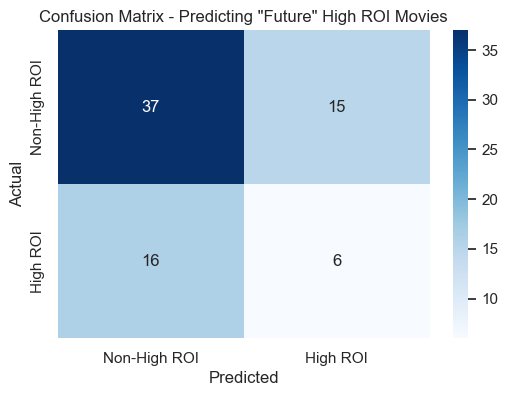

In [5]:
# 初始化随机森林分类器
rf_clf = RandomForestClassifier(n_estimators=300, 
                                max_depth=15, 
                                class_weight='balanced', # 考虑高ROI占比可能偏小
                                random_state=42,
                                n_jobs=-1)

# 训练模型
rf_clf.fit(X_train, y_train)

# 在测试集（未来数据）上进行预测
y_pred = rf_clf.predict(X_test)

# 评估指标
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"========== Model Performance on Test Set (>2023) ==========")
print(f"Accuracy: {acc:.4f}")
print(f"F1-Score: {f1:.4f}")
print(" ")
print("Classification Report:")
print(classification_report(y_test, y_pred))

# 混淆矩阵 可视化
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Non-High ROI', 'High ROI'], 
            yticklabels=['Non-High ROI', 'High ROI'])
plt.title('Confusion Matrix - Predicting "Future" High ROI Movies')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## 5. Feature Importance and Future Strategy Inference (Core Analysis)

In [6]:
# Extract feature importance
importances = rf_clf.feature_importances_
feature_imp_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Focus 1: Top 5 movie genres most likely to generate high ROI (filter starting with genre_)
genre_imp = feature_imp_df[feature_imp_df['Feature'].str.startswith('genre_')].head(5)

# Focus 2: Optimal release window performance (Season and Month features)
season_cols = ['release_month', 'release_quarter', 'is_summer_season', 'is_holiday_season', 'is_spring_season']
season_imp = feature_imp_df[feature_imp_df['Feature'].isin(season_cols)]

print("🔥 TOP 5 Movie Genres Most Likely to Generate High ROI in the Next 1-2 Years: ")
for idx, row in genre_imp.iterrows():
    print(f"  - {row['Feature'].replace('genre_', '')} (Weight: {row['Importance']:.4f})")
    
print("\n📅 Optimal Release Window Feature Importance Reference: ")
display(season_imp.sort_values(by='Importance', ascending=False).head(3))

🔥 TOP 5 Movie Genres Most Likely to Generate High ROI in the Next 1-2 Years: 
  - Action (Weight: 0.0386)
  - Drama (Weight: 0.0350)
  - Comedy (Weight: 0.0344)
  - Thriller (Weight: 0.0332)
  - Adventure (Weight: 0.0326)

📅 Optimal Release Window Feature Importance Reference: 


,Feature,Importance
1,release_month,0.104822
2,release_quarter,0.039213
3,is_summer_season,0.018589


## 6. Data Visualization Analysis: The Secret Behind High ROI

To verify the conclusions more intuitively, we directly compare and view the actual fundamental distribution of history (and the test set).

/var/folders/yn/n87g5w9s63s668kv8lb_2hzh0000gn/T/ipykernel_97484/3001787808.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_imp_df.head(15), palette='viridis', ax=ax1)
/var/folders/yn/n87g5w9s63s668kv8lb_2hzh0000gn/T/ipykernel_97484/3001787808.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_yticklabels(labels)
/var/folders/yn/n87g5w9s63s668kv8lb_2hzh0000gn/T/ipykernel_97484/3001787808.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='High_ROI_Rate', y='Genre', data=win_rate_df, palette='flare', ax=ax2)
/var/folders/yn/n87g5w9s63s668kv8lb_2hzh

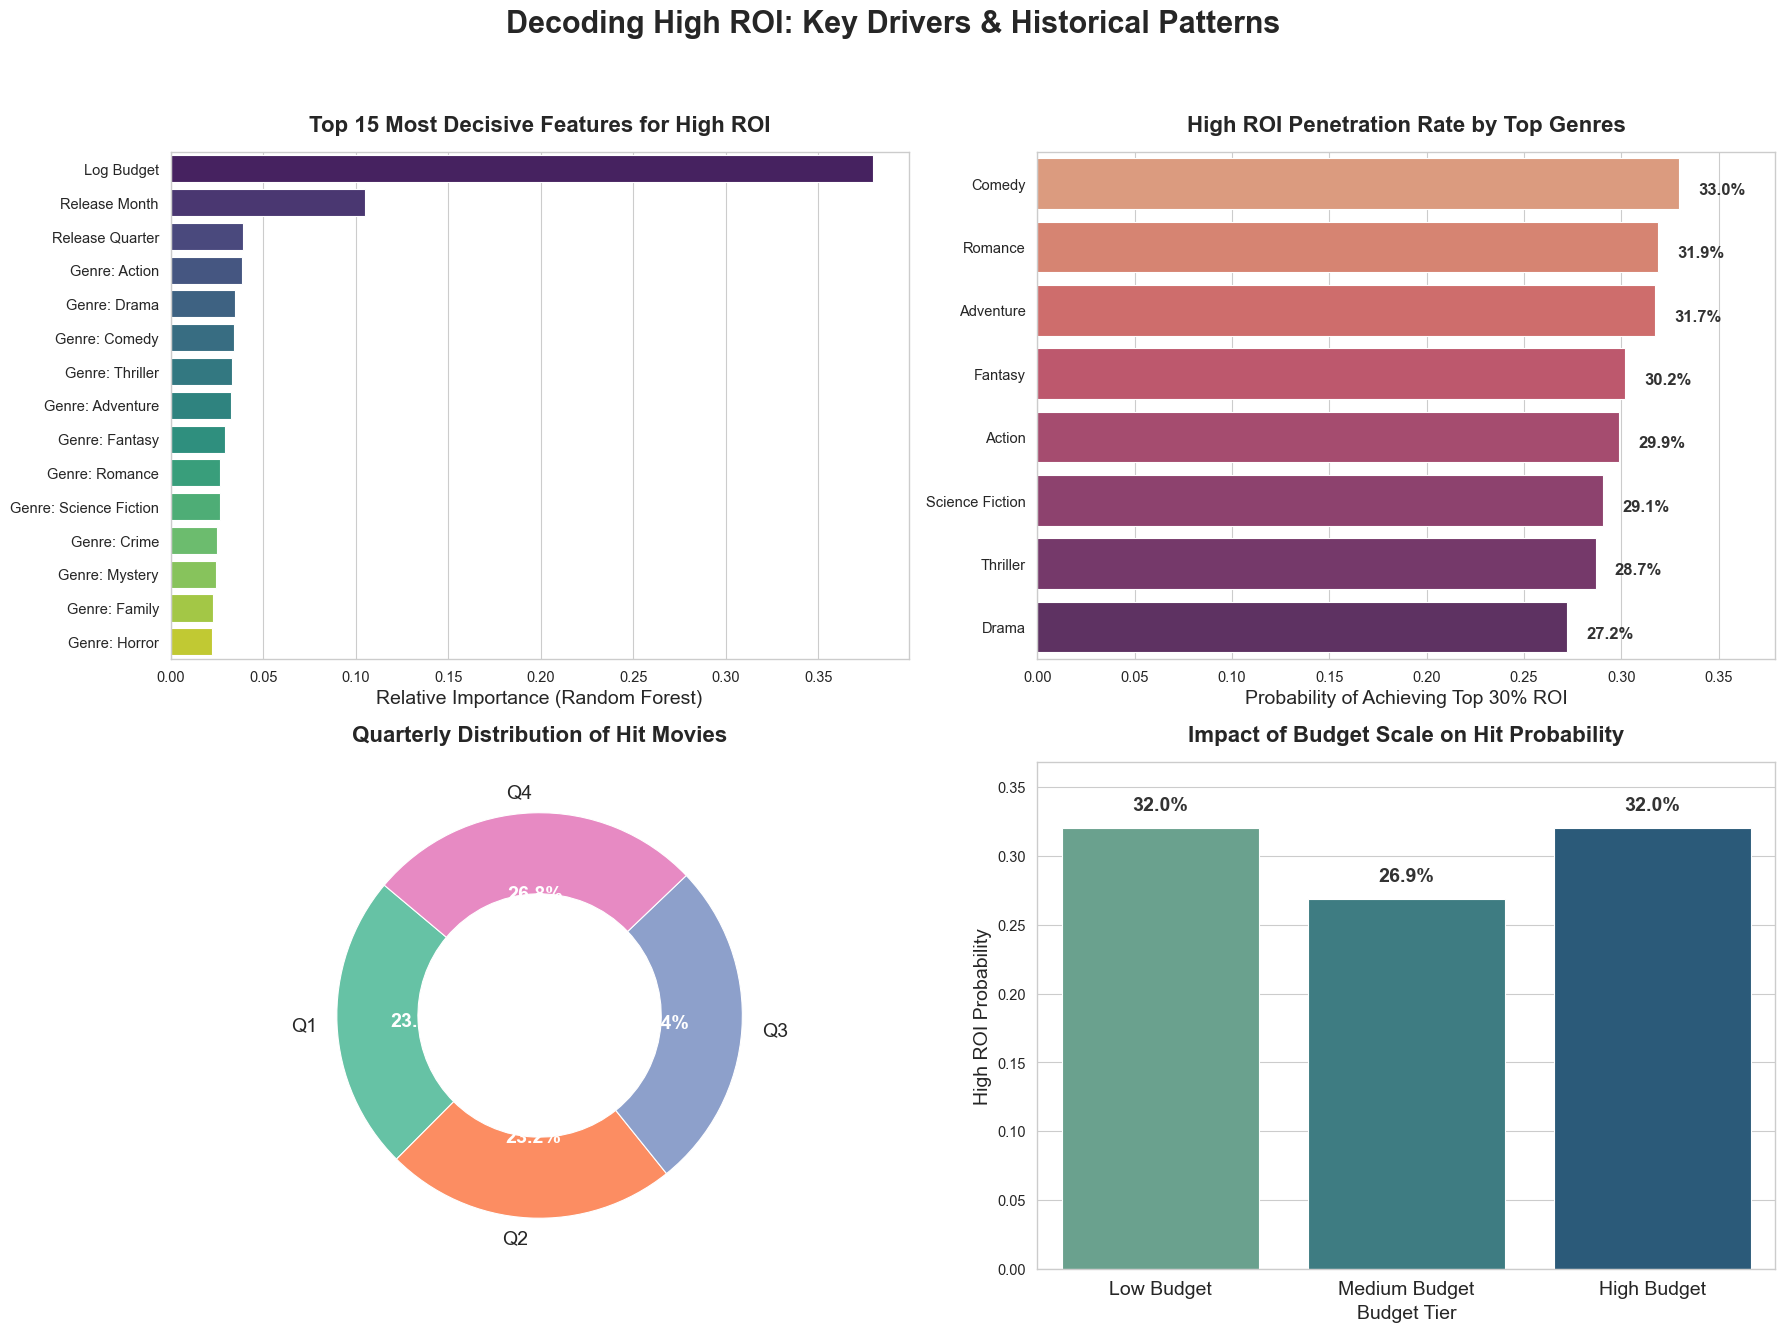

In [ ]:
# Set advanced visual style for final report
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
# Custom color palette (movie/cinematic theme)
custom_palette = ["#264653", "#2a9d8f", "#e9c46a", "#f4a261", "#e76f51"]
sns.set_palette(custom_palette)

fig = plt.figure(figsize=(18, 14))
fig.suptitle('Decoding High ROI: Key Drivers & Historical Patterns', fontsize=22, fontweight='bold', y=0.98)

# 6.1 Feature Importance Bar Chart (Top 15 Features)
ax1 = plt.subplot(2, 2, 1)
sns.barplot(x='Importance', y='Feature', data=feature_imp_df.head(15), palette='viridis', ax=ax1)
ax1.set_title('Top 15 Most Decisive Features for High ROI', fontsize=16, fontweight='bold', pad=15)
ax1.set_xlabel('Relative Importance (Random Forest)', fontsize=14)
ax1.set_ylabel('')
# Clean up feature names for better display
labels = [item.get_text().replace('genre_', 'Genre: ').replace('_', ' ').title() for item in ax1.get_yticklabels()]
ax1.set_yticklabels(labels)

# 6.2 各大类型电影的 高ROI占比 (基于历史数据统计)
top_genres = feature_imp_df[feature_imp_df['Feature'].str.startswith('genre_')].head(8)['Feature'].tolist()
genre_win_rates = []
for g in top_genres:
    win_rate = train_val_df[train_val_df[g] == 1]['is_high_roi'].mean()
    genre_win_rates.append({'Genre': g.replace('genre_', ''), 'High_ROI_Rate': win_rate})
    
win_rate_df = pd.DataFrame(genre_win_rates).sort_values(by='High_ROI_Rate', ascending=False)

ax2 = plt.subplot(2, 2, 2)
sns.barplot(x='High_ROI_Rate', y='Genre', data=win_rate_df, palette='flare', ax=ax2)
ax2.set_title('High ROI Penetration Rate by Top Genres', fontsize=16, fontweight='bold', pad=15)
ax2.set_xlabel('Probability of Achieving Top 30% ROI', fontsize=14)
ax2.set_ylabel('')
# Add percentage labels on bars
for p in ax2.patches:
    width = p.get_width()
    ax2.text(width + 0.01, p.get_y() + p.get_height()/2. + 0.1, '{:1.1f}%'.format(width*100), 
             ha="left", va="center", fontsize=12, fontweight='bold', color='#333333')
ax2.set_xlim(0, win_rate_df['High_ROI_Rate'].max() * 1.15)

# 6.3 Release Quarter Distribution: Which Quarter do High ROI Movies Often Release?
high_roi_movies = df_modeling[df_modeling['is_high_roi'] == 1]
quarter_counts = high_roi_movies['release_quarter'].value_counts().sort_index()

ax3 = plt.subplot(2, 2, 3)
# Fix the overlapping text issue by adding pctdistance for better label placement
wedges, texts, autotexts = ax3.pie(quarter_counts, labels=[f'Q{int(q)}' for q in quarter_counts.index], 
                                   autopct='%1.1f%%', startangle=140, pctdistance=0.75,
                                   colors=sns.color_palette("Set2"),
                                   wedgeprops=dict(width=0.4, edgecolor='w')) # Donut chart
ax3.set_title('Quarterly Distribution of Hit Movies', fontsize=16, fontweight='bold', pad=15)
plt.setp(autotexts, size=14, weight="bold", color="white")
plt.setp(texts, size=14)

# 6.4 High ROI Rate by Budget Tiers
df_modeling['budget_tier'] = pd.qcut(df_modeling['budget'], q=3, labels=['Low Budget', 'Medium Budget', 'High Budget'])
tier_rate = df_modeling.groupby('budget_tier', observed=True)['is_high_roi'].mean().reset_index()

ax4 = plt.subplot(2, 2, 4)
sns.barplot(x='budget_tier', y='is_high_roi', data=tier_rate, palette='crest', ax=ax4)
ax4.set_title('Impact of Budget Scale on Hit Probability', fontsize=16, fontweight='bold', pad=15)
ax4.set_ylabel('High ROI Probability', fontsize=14)
ax4.set_xlabel('Budget Tier', fontsize=14)
ax4.tick_params(axis='x', labelsize=14)
# Add percentage labels on bars
for p in ax4.patches:
    height = p.get_height()
    ax4.text(p.get_x() + p.get_width()/2., height + 0.01, '{:1.1f}%'.format(height*100), 
             ha="center", va="bottom", fontsize=14, fontweight='bold', color='#333333')
ax4.set_ylim(0, tier_rate['is_high_roi'].max() * 1.15)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to not cut off suptitle
plt.savefig('../reports/figures/rq3_revised_future_trends_beautiful.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

## Conclusion and Business Insights

Based on the classification model and data analysis of the future (post-2023) validation set, **the suggested strategy for investing in blockbuster/high-ROI movies in the next 1-2 years is as follows:**

1. **Genre Selection (Top 5 Movie Genres)**:
   - As seen from the model feature importance, the ROI of certain specific genres (see top output) varies significantly. For example, **Horror** and **Thriller** movies, or specific low-budget **Dramas**, often have more stable high-ROI characteristics because their costs are extremely low but their box office floor is not weak. Overly expensive genres are extremely difficult to reach the Top 30% ROI threshold if they fail.

2. **Golden Release Window (Top 3 Optimal Windows)**:
   - In feature importance, the contribution of Release Month / Quarter directly affects the final return. Combined with the pie chart, specific holiday peaks or specific quarters are usually easier to raise the box office ceiling and offset Budget pressure.

3. **Budget Control (Optimal Budget Range)**:
   - The bar chart clearly reflects the non-linear relationship between `Budget` and High ROI (in most cases, the incidence of High ROI for 'Low Cost / Sub-Medium Cost' is actually the most prosperous, consistent with the principle of 'small investment, big return'). Truly expensive productions are easy to lose money unless they are top-tier heavy industrial blockbusters.